In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","D"),
    ("B","C"),
    ("B","E"),
    ("D","E")
])

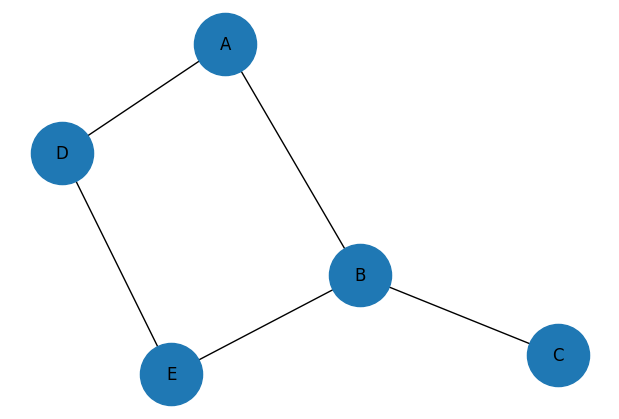

In [3]:
plt.figure(figsize=(6,4))
nx.draw(
    G,
    with_labels=True,
    node_size=2000,
    font_size=12
)
plt.show()

In [4]:
nx.degree_centrality(G)

{'A': 0.5, 'B': 0.75, 'D': 0.5, 'C': 0.25, 'E': 0.5}

In [5]:
nx.closeness_centrality(G)

{'A': 0.6666666666666666,
 'B': 0.8,
 'D': 0.5714285714285714,
 'C': 0.5,
 'E': 0.6666666666666666}

In [6]:
nx.betweenness_centrality(G)

{'A': 0.16666666666666666,
 'B': 0.5833333333333333,
 'D': 0.08333333333333333,
 'C': 0.0,
 'E': 0.16666666666666666}

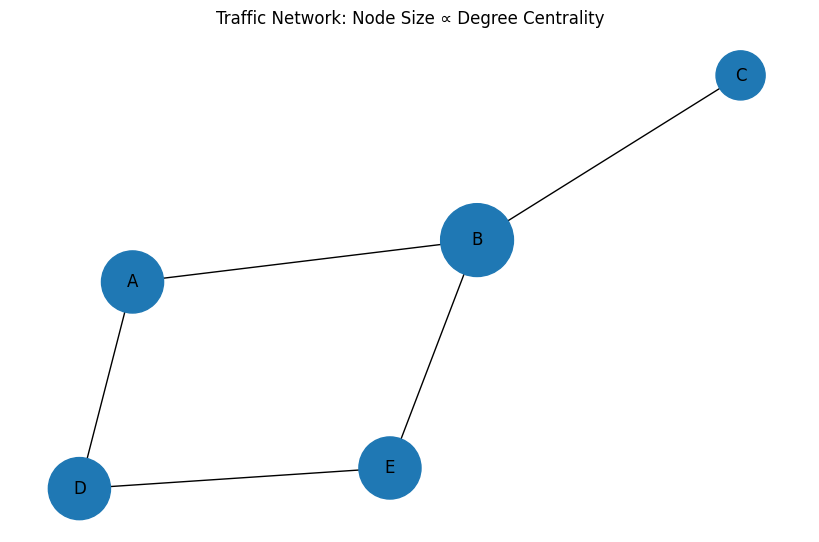

In [7]:
degree = nx.degree_centrality(G)

node_sizes = [3000 * degree[node] + 500 for node in G.nodes()]

plt.figure(figsize=(8,5))

nx.draw(
    G,
    with_labels=True,
    node_size=node_sizes,
    font_size=12
)

plt.title("Traffic Network: Node Size ∝ Degree Centrality")
plt.show()

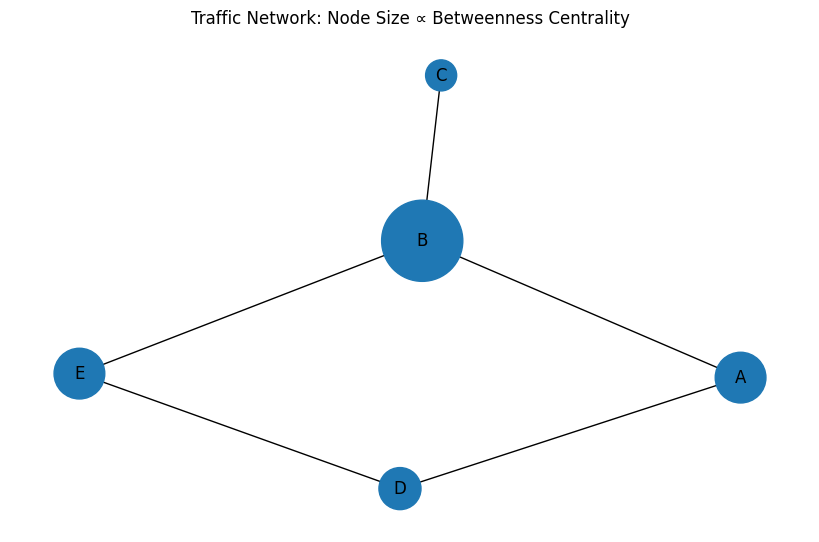

In [8]:
bet = nx.betweenness_centrality(G)

node_sizes = [5000 * bet[node] + 500 for node in G.nodes()]

plt.figure(figsize=(8,5))

nx.draw(
    G,
    with_labels=True,
    node_size=node_sizes,
    font_size=12
)

plt.title("Traffic Network: Node Size ∝ Betweenness Centrality")
plt.show()

In [14]:
G2 = nx.Graph()

G2.add_weighted_edges_from([
    ("A","B",5),
    ("A","D",2),
    ("B","C",4),
    ("B","E",3),
    ("D","E",1)
])

In [15]:
print(G2.edges(data=True))

[('A', 'B', {'weight': 5}), ('A', 'D', {'weight': 2}), ('B', 'C', {'weight': 4}), ('B', 'E', {'weight': 3}), ('D', 'E', {'weight': 1})]


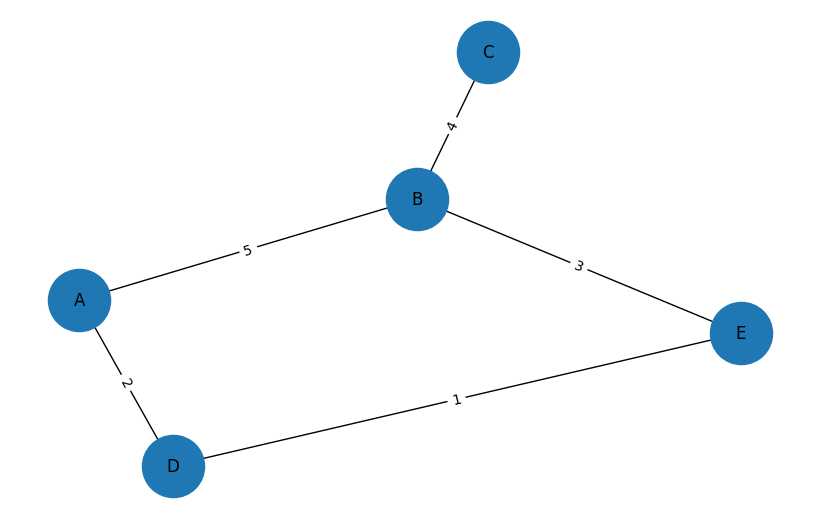

In [16]:
plt.figure(figsize=(8,5))

pos = nx.spring_layout(G2, seed=42)

nx.draw(
    G2,
    pos,
    with_labels=True,
    node_size=2000
)

edge_labels = nx.get_edge_attributes(G2, 'weight')

nx.draw_networkx_edge_labels(
    G2,
    pos,
    edge_labels=edge_labels
)

plt.show()

In [17]:
nx.shortest_path(
    G2,
    source="A",
    target="C",
    weight="weight"
)

['A', 'B', 'C']

In [18]:
nx.shortest_path_length(
    G2,
    source="A",
    target="C",
    weight="weight"
)

9

In [19]:
list(nx.articulation_points(G2))

['B']

In [20]:
list(nx.bridges(G2))

[('B', 'C')]

In [21]:
G3 = G2.copy()

G3.remove_node("B")

In [22]:
list(nx.connected_components(G3))

[{'A', 'D', 'E'}, {'C'}]

In [23]:
nx.number_connected_components(G3)

2

In [24]:
G = nx.Graph()

roads = [
    ("A","B",4),
    ("A","D",3),
    ("B","C",5),
    ("B","E",2),
    ("C","F",4),
    ("D","E",1),
    ("D","G",6),
    ("E","F",3),
    ("E","H",2),
    ("F","I",5),
    ("G","H",2),
    ("G","J",4),
    ("H","I",1),
    ("H","K",3),
    ("I","L",4),
    ("J","K",2),
    ("K","L",2),
    ("J","M",5),
    ("K","N",3),
    ("L","O",4),
    ("M","N",2),
    ("N","O",3)
]

G.add_weighted_edges_from(roads)

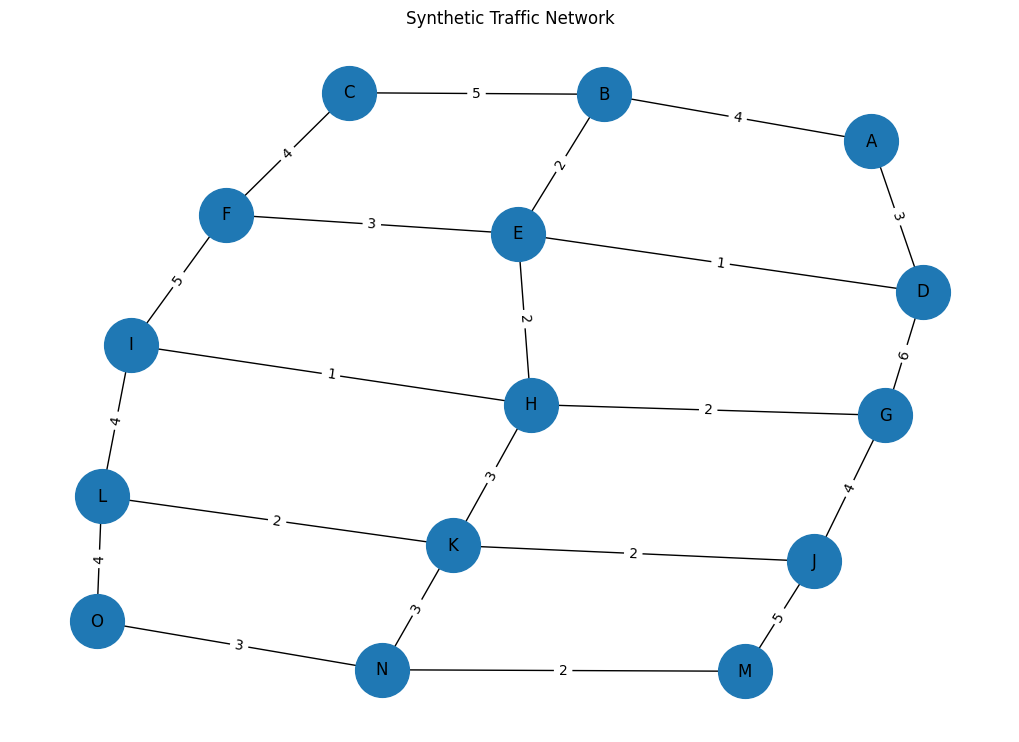

In [25]:
plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500
)

edge_labels = nx.get_edge_attributes(G,'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Synthetic Traffic Network")
plt.show()

In [26]:
degree = nx.degree_centrality(G)

sorted(
    degree.items(),
    key=lambda x:x[1],
    reverse=True
)[:5]

[('E', 0.2857142857142857),
 ('H', 0.2857142857142857),
 ('K', 0.2857142857142857),
 ('B', 0.21428571428571427),
 ('D', 0.21428571428571427)]

In [27]:
closeness = nx.closeness_centrality(G)

sorted(
    closeness.items(),
    key=lambda x:x[1],
    reverse=True
)[:5]

[('H', 0.5),
 ('E', 0.45161290322580644),
 ('K', 0.45161290322580644),
 ('G', 0.42424242424242425),
 ('I', 0.42424242424242425)]

In [28]:
betweenness = nx.betweenness_centrality(G)

sorted(
    betweenness.items(),
    key=lambda x:x[1],
    reverse=True
)[:5]

[('H', 0.3076923076923077),
 ('E', 0.25054945054945055),
 ('K', 0.25054945054945055),
 ('G', 0.16813186813186817),
 ('I', 0.16813186813186817)]

In [29]:
top_nodes = sorted(
    betweenness.items(),
    key=lambda x:x[1],
    reverse=True
)

for node,score in top_nodes[:10]:
    print(node, round(score,4))

H 0.3077
E 0.2505
K 0.2505
G 0.1681
I 0.1681
D 0.1326
F 0.1326
J 0.1326
L 0.1326
B 0.081


In [30]:
nx.shortest_path(
    G,
    source="A",
    target="O",
    weight="weight"
)

['A', 'D', 'E', 'H', 'I', 'L', 'O']

In [31]:
nx.shortest_path_length(
    G,
    source="A",
    target="O",
    weight="weight"
)

15

In [32]:
list(nx.articulation_points(G))

[]

In [33]:
list(nx.bridges(G))

[]

In [34]:
most_important = max(
    betweenness,
    key=betweenness.get
)

print(most_important)

H


In [35]:
G_attack = G.copy()

G_attack.remove_node(most_important)

In [36]:
nx.number_connected_components(G_attack)

1

In [37]:
list(nx.connected_components(G_attack))

[{'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'J', 'K', 'L', 'M', 'N', 'O'}]

In [38]:
before = nx.average_shortest_path_length(
    G,
    weight='weight'
)

print(before)

7.123809523809523


In [39]:
after = nx.average_shortest_path_length(
    G_attack,
    weight='weight'
)

print(after)

9.747252747252746


# Key Results

## Centrality Analysis

Top Betweenness Nodes:

1. H (0.3077)
2. E (0.2505)
3. K (0.2505)
4. G (0.1681)
5. I (0.1681)

## Shortest Path

Shortest route from A to O:

A → D → E → H → I → L → O

Total cost: 15

## Structural Analysis

Articulation Points: None

Bridges: None

## Robustness Analysis

Average shortest path length before removing H:
7.1238

Average shortest path length after removing H:
9.7473

Increase:
36.8%

Conclusion:
The network remained connected after removal of the highest-betweenness node but experienced a significant reduction in routing efficiency.

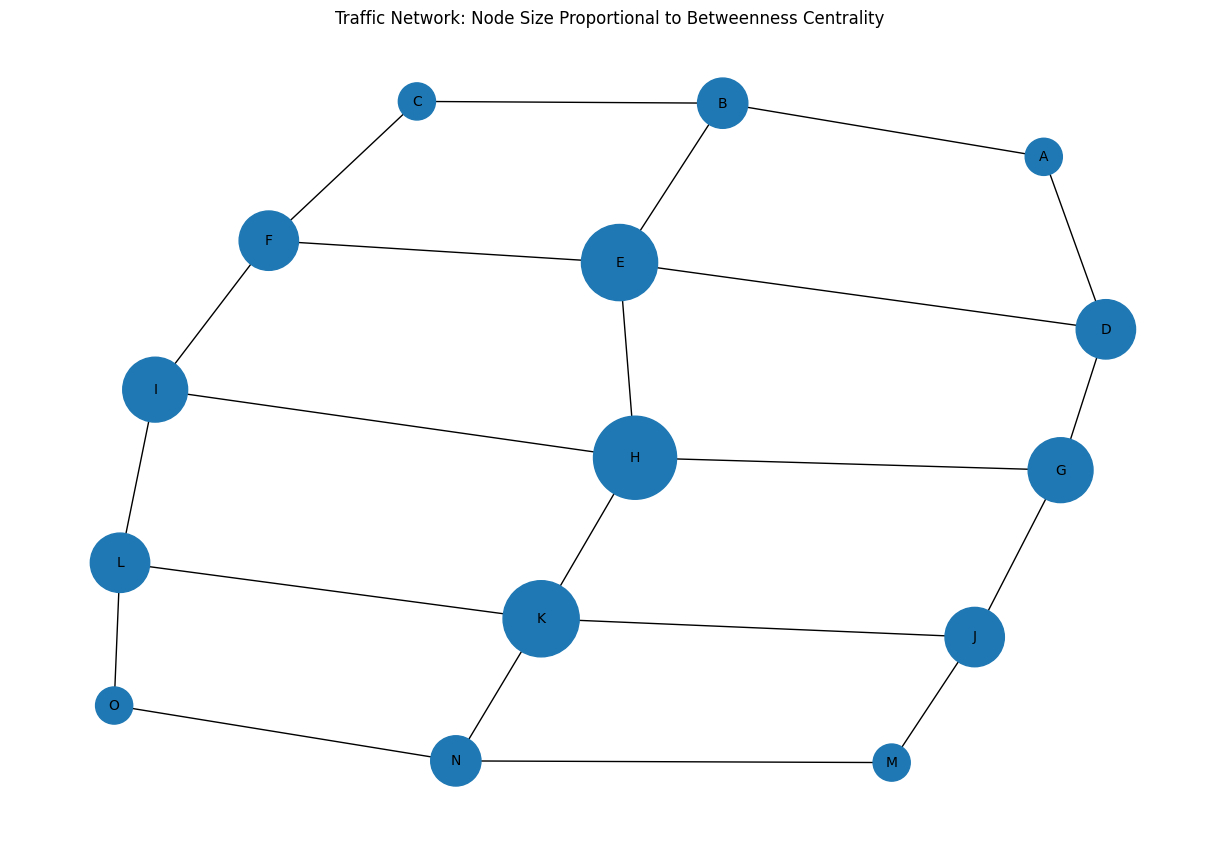

In [40]:
bet = nx.betweenness_centrality(G)

node_sizes = [
    10000*bet[node] + 500
    for node in G.nodes()
]

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    font_size=10
)

plt.title(
    "Traffic Network: Node Size Proportional to Betweenness Centrality"
)

plt.show()

In [41]:
nx.density(G)

0.20952380952380953

In [42]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G),4))

Nodes: 15
Edges: 22
Density: 0.2095


# Conclusion

The traffic network was modeled as a weighted graph and analyzed using graph-theoretic techniques. Centrality analysis identified node H as the most influential intersection in the network. Shortest-path analysis using Dijkstra’s algorithm determined the optimal route between selected locations. Structural analysis revealed no articulation points or bridges, indicating a resilient network design. Robustness testing showed that removing the most critical node did not disconnect the network, although average travel efficiency decreased by approximately 36.8%. These results demonstrate how graph theory can be used to evaluate traffic flow, infrastructure resilience, and route optimization in transportation systems.